# Coastal Universities of Africa

A map of Africa marking significant universities in coastal cities, on the same
Orthographic globe projection as the KE figure (`cson_map_ke_africa.ipynb`),
with a natural geographic feel (Natural Earth I shaded relief) and political
country borders. The Technical University of Mombasa and the (inland)
University of Nairobi are included.

Edit the `UNIVERSITIES` list to add/move institutions; the `dx, dy` fields are
label offsets in **points** (projection-independent) with a leader line.

In [1]:
import os, glob, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray

CACHE = os.path.expanduser("~/Library/Caches/roms-tools")

# Orthographic globe centred on Africa -- same projection as the KE figure
CENTER_LON, CENTER_LAT = 20.0, 10.0
CROP = dict(lon=(-100, 130), lat=(-88, 88))   # basemap crop covering the visible hemisphere

# Natural Earth I colour shaded relief (downloaded once into the cache)
_dir = os.path.join(CACHE, "NE1_50M_SR_W")
_hits = glob.glob(os.path.join(_dir, "**", "NE1_50M_SR_W.tif"), recursive=True)
if not _hits:
    _zp = os.path.join(CACHE, "NE1_50M_SR_W.zip")
    urllib.request.urlretrieve(
        "https://naturalearth.s3.amazonaws.com/50m_raster/NE1_50M_SR_W.zip", _zp)
    with zipfile.ZipFile(_zp) as z:
        z.extractall(_dir)
    os.remove(_zp)
    _hits = glob.glob(os.path.join(_dir, "**", "NE1_50M_SR_W.tif"), recursive=True)
NE1_PATH = _hits[0]

# name, lon, lat, label dx, dy (points, projection-independent), horizontal alignment
UNIVERSITIES = [
    ("Cheikh Anta Diop Univ.\nDakar",            -17.46, 14.68, -55,  18, "right"),
    ("Univ. F. Houphou\u00ebt-Boigny\nAbidjan",  -3.99,  5.35, -72, -22, "right"),
    ("Univ. of Ghana\nAccra",                     -0.19,  5.65, -34, -56, "right"),
    ("Univ. of Lagos",                              3.40,  6.52,  -4, -82, "center"),
    ("Univ. of Calabar",                            8.34,  4.95,  30, -66, "center"),
    ("Univ. of Douala",                             9.70,  4.05,  82, -24, "left"),
    ("Agostinho Neto Univ.\nLuanda",              13.23, -8.84, -58, -16, "right"),
    ("Univ. of Cape Town",                         18.46, -33.96, -35, -45, "right"),
    ("Nelson Mandela Univ.\nGqeberha",            25.60, -33.96,  12, -52, "center"),
    ("Univ. of KwaZulu-Natal\nDurban",            30.95, -29.82,  55, -18, "left"),
    ("Eduardo Mondlane Univ.\nMaputo",            32.60, -25.97,  62, -22, "left"),
    ("Univ. of Dar es Salaam",                     39.21, -6.77,   62, -12, "left"),
    ("Technical Univ. of Mombasa",                 39.66, -4.04,   64,   8, "left"),
    ("Univ. of Nairobi",                           36.82, -1.29,  -46,  40, "right"),
    ("Somali National Univ.\nMogadishu",          45.32,  2.05,   55,  16, "left"),
]

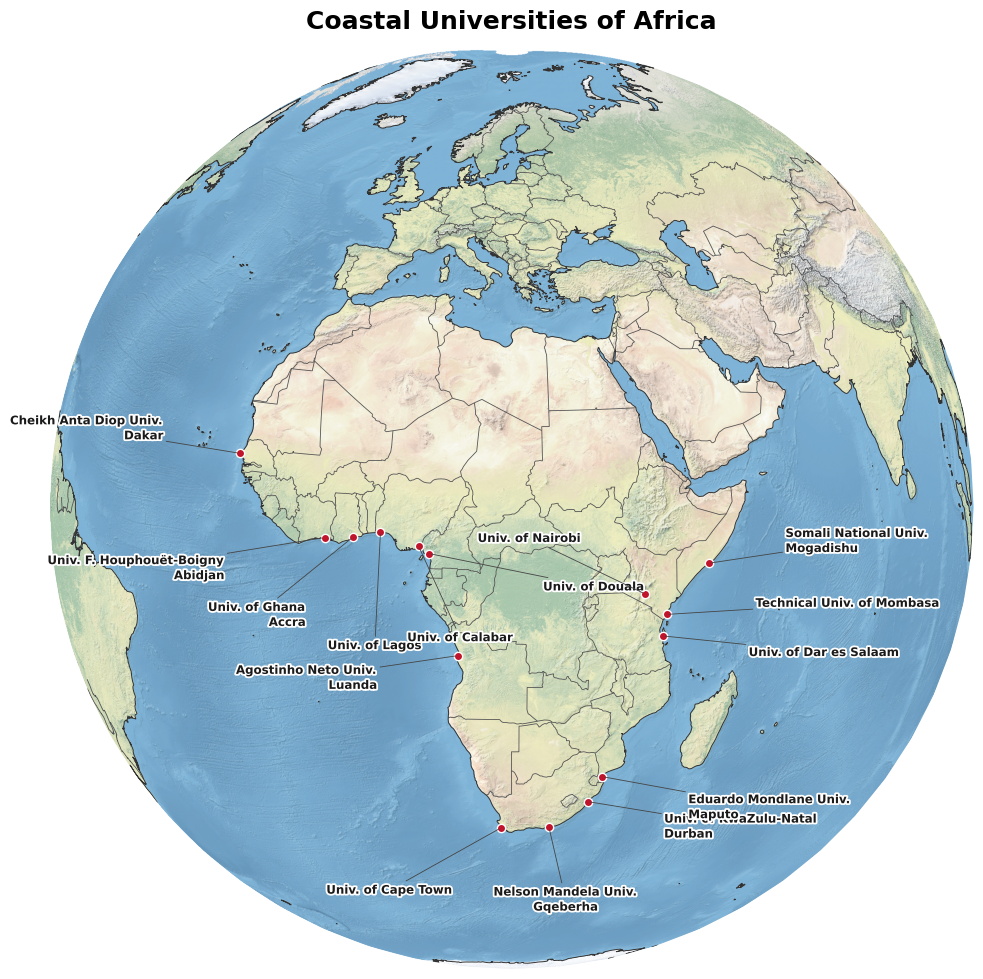

In [2]:
# Natural-relief basemap, warped onto the orthographic globe
ne = rioxarray.open_rasterio(NE1_PATH).sel(
    x=slice(CROP["lon"][0], CROP["lon"][1]), y=slice(CROP["lat"][1], CROP["lat"][0]))
img = np.moveaxis(ne.values, 0, -1) / 255.0
img_extent = [float(ne.x.min()), float(ne.x.max()), float(ne.y.min()), float(ne.y.max())]

prj = ccrs.Orthographic(central_longitude=CENTER_LON, central_latitude=CENTER_LAT)
pc = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection=prj))
fig.patch.set_facecolor("none")
ax.imshow(img, extent=img_extent, origin="upper", transform=pc, zorder=0, regrid_shape=2000)

# Political layer: country borders + coastline
ax.add_feature(cfeature.NaturalEarthFeature(
    "cultural", "admin_0_boundary_lines_land", "50m",
    edgecolor="#555555", facecolor="none", linewidth=0.6), zorder=2)
ax.coastlines("50m", linewidth=0.7, color="#333333", zorder=3)
ax.set_global()
ax.spines["geo"].set_visible(False)

halo = [pe.withStroke(linewidth=2.6, foreground="white")]
anchor = pc._as_mpl_transform(ax)
for name, lon, lat, dx, dy, ha in UNIVERSITIES:
    ax.plot(lon, lat, marker="o", ms=6, mfc="#c0142b", mec="white", mew=1.0,
            transform=pc, zorder=5)
    ax.annotate(name, xy=(lon, lat), xycoords=anchor, xytext=(dx, dy),
                textcoords="offset points", ha=ha, va="center", fontsize=8.5,
                fontweight="bold", color="#1a1a1a", zorder=6, path_effects=halo,
                arrowprops=dict(arrowstyle="-", color="#444444", lw=0.6,
                                shrinkA=0, shrinkB=2))

ax.set_title("Coastal Universities of Africa", fontsize=18, fontweight="bold", pad=12)
fig.savefig("africa-coastal-universities.png", dpi=160, bbox_inches="tight", transparent=True)
plt.show()